# EDA for Animals Dataset

In [57]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import random

from PIL import Image
import cv2
from collections import defaultdict
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops

Display the number of images per model and class

In [13]:
base_path = "data"
fake_base_path = os.path.join(base_path, "fake")
real_base_path = os.path.join(base_path, "real")
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')

real_counts = {}
total_real = 0

fake_counts = {}
total_fake = 0

for subfolder in os.listdir(fake_base_path):
    subfolder_path = os.path.join(fake_base_path, subfolder)

    if not os.path.isdir(subfolder_path):
        continue

    else:
        images = [f for f in os.listdir(subfolder_path) if f.lower().endswith(image_extensions)]
        count = len(images)
        fake_counts[subfolder] = count
        total_fake += count

for subfolder in os.listdir(real_base_path):
    subfolder_path = os.path.join(real_base_path, subfolder)

    if not os.path.isdir(subfolder_path):
        continue

    else:
        images = [f for f in os.listdir(subfolder_path) if f.lower().endswith(image_extensions)]
        count = len(images)
        real_counts[subfolder] = count
        total_real += count

total_images = total_real + total_fake
real_percentage = (total_real / total_images) * 100 if total_images > 0 else 0
fake_percentage = (total_fake / total_images) * 100 if total_images > 0 else 0

# --- Output ---
print(f"Real image breakdown:")
for subfolder, count in real_counts.items():
    percentage = (count / total_real) * 100 if total_real > 0 else 0
    print(f"  - {subfolder}: {count} images ({percentage:.2f}%)")

print(f"AI-generated image breakdown:")
for subfolder, count in fake_counts.items():
    percentage = (count / total_fake) * 100 if total_fake > 0 else 0
    print(f"  - {subfolder}: {count} images ({percentage:.2f}%)")

print(f"\nDataset Summary:")
print(f"  Total AI-generated images: {total_fake}")
print(f"  Total real images: {total_real}")
print(f"  Total images: {total_images}")
print(f"  % Real: {real_percentage:.2f}%")
print(f"  % AI-generated: {fake_percentage:.2f}%")

Real image breakdown:
  - afhq: 31864 images (36.27%)
  - lsun: 50000 images (56.91%)
  - pro_gan: 6000 images (6.83%)
AI-generated image breakdown:
  - cycle_gan: 5322 images (8.68%)
  - pro_gan: 6000 images (9.78%)
  - style_gan: 50000 images (81.54%)

Dataset Summary:
  Total AI-generated images: 61322
  Total real images: 87864
  Total images: 149186
  % Real: 58.90%
  % AI-generated: 41.10%


### Selecting a subset of the data

In [29]:
base_path = 'data_resized'
subset_path = 'data_subset'
os.makedirs(subset_path, exist_ok=True)
class_names = {0: 'Real', 1: 'AI'}

n_images = 10

for label, class_name in class_names.items():
    class_dir = os.path.join(base_path, str(label))
    subset_class_dir = os.path.join(subset_path, str(label))
    os.makedirs(subset_class_dir, exist_ok=True)

    all_files = os.listdir(class_dir)
    selected_files = random.sample(all_files, min(n_images, len(all_files)))

    for file_name in selected_files:
        src_file = os.path.join(class_dir, file_name)
        dst_file = os.path.join(subset_class_dir, file_name)
        shutil.copy2(src_file, dst_file)

print("Subset created in:", subset_path)

Subset created in: data_subset


## Edge Detection

In [49]:
# helper functions

def compute_sobel_grad(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 1.4)
    
    # Sobel operators
    Gx = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(Gx**2 + Gy**2)

    # normalize to range 0-255
    Gx = np.uint8(255 * np.abs(Gx) / np.max(Gx))
    Gy = np.uint8(255 * np.abs(Gy) / np.max(Gy))
    mag = np.uint8(255 * mag / np.max(mag)) 

    return (Gx, Gy, mag)


def compute_prewitt_grad(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # horizontal Prewitt kernel
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]])
    horizontal_edges = cv2.filter2D(gray_image, -1, kernel_x)
    
    # vertical Prewitt kernel
    kernel_y = np.array([[-1, -1, -1],
                         [0, 0, 0],
                         [1, 1, 1]])
    vertical_edges = cv2.filter2D(gray_image, -1, kernel_y)    
    
    horizontal_edges = np.float32(horizontal_edges)
    vertical_edges = np.float32(vertical_edges)
    
    gradient_magnitude = cv2.magnitude(horizontal_edges, vertical_edges)
    
    # highlight edges
    threshold = 50
    _, edges = cv2.threshold(gradient_magnitude, threshold, 255, cv2.THRESH_BINARY)
    
    return edges

#### Sobel & Prewitt Edge Detection

In [54]:
sobel_grads = {0: {}, 1: {}}
prewitt_grads = {0: {}, 1: {}}


for class_id in [0, 1]:
    class_path = os.path.join(subset_path, str(class_id))
    
    for file_name in os.listdir(class_path):
         # load image
        image_path = os.path.join(class_path, file_name)
        sobel_grads[class_id][image_path] = compute_sobel_grad(image_path)
        prewitt_grads[class_id][image_path] = compute_prewitt_grad(image_path)

#### Plot Real Image Edge Detection

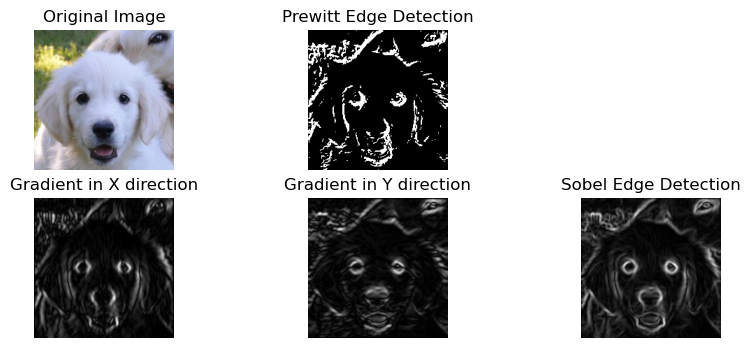

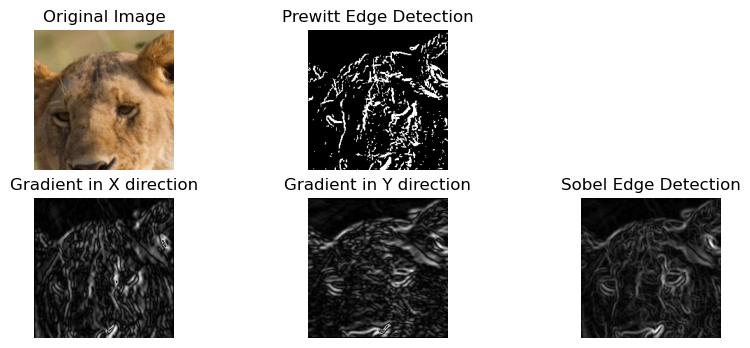

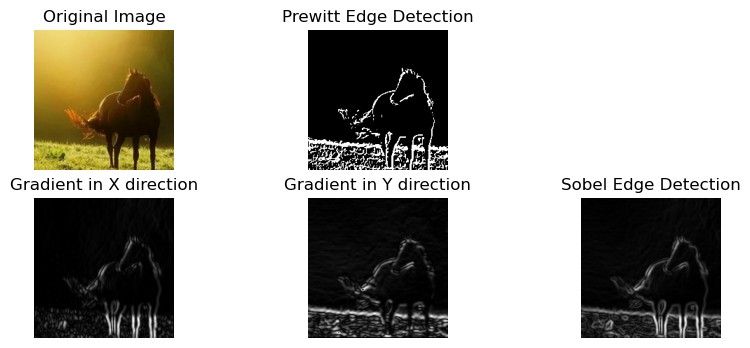

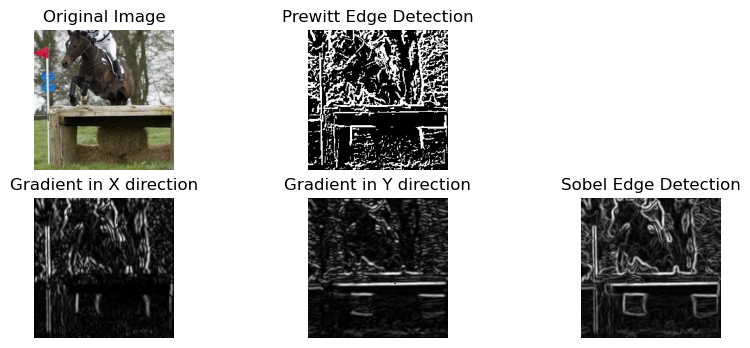

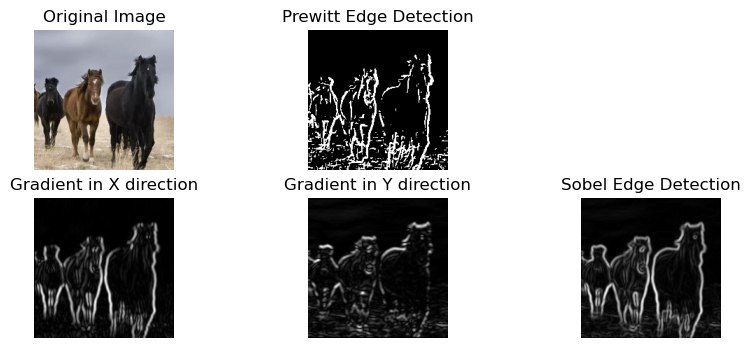

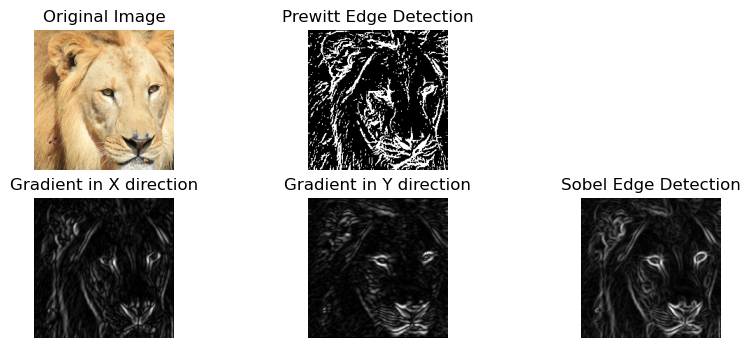

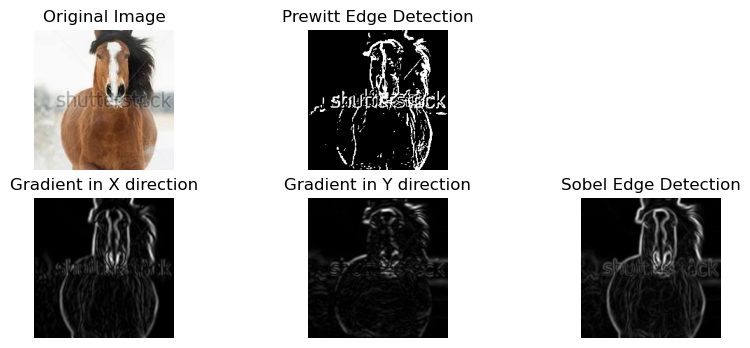

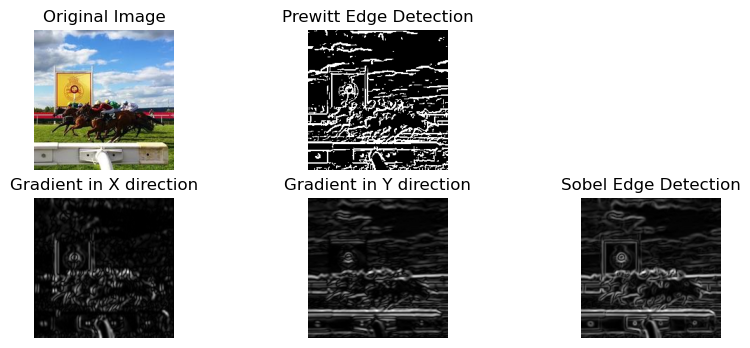

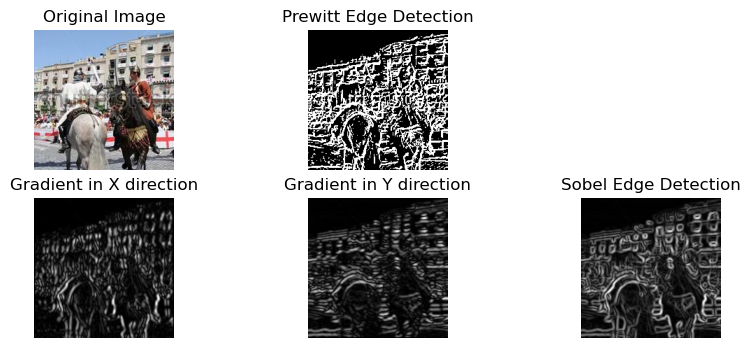

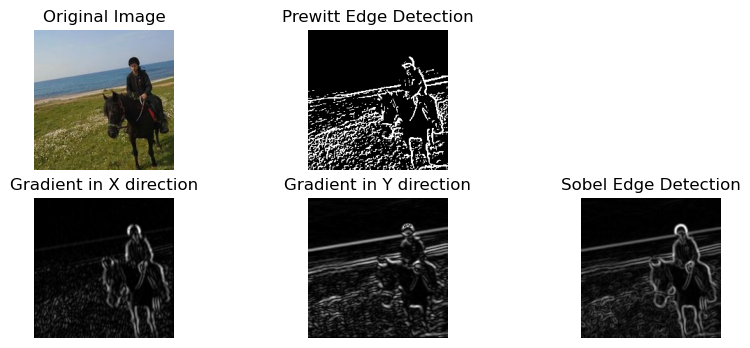

In [55]:
for img, grads in gradient_data[0].items():
    image = cv2.imread(img, cv2.IMREAD_COLOR)
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(prewitt_grads[0][img], cmap='gray')
    plt.title('Prewitt Edge Detection')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(grads[0], cmap='gray')
    plt.title('Gradient in X direction')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.imshow(grads[1], cmap='gray')
    plt.title('Gradient in Y direction')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(grads[2], cmap='gray')
    plt.title('Sobel Edge Detection')
    plt.axis('off')

    plt.show()

#### Plot AI-Generated Image Edge Detection

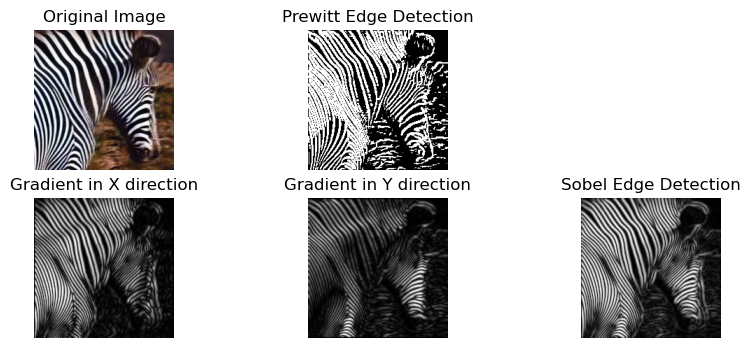

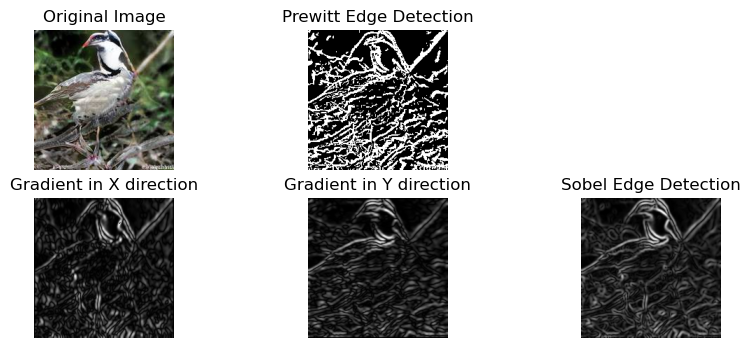

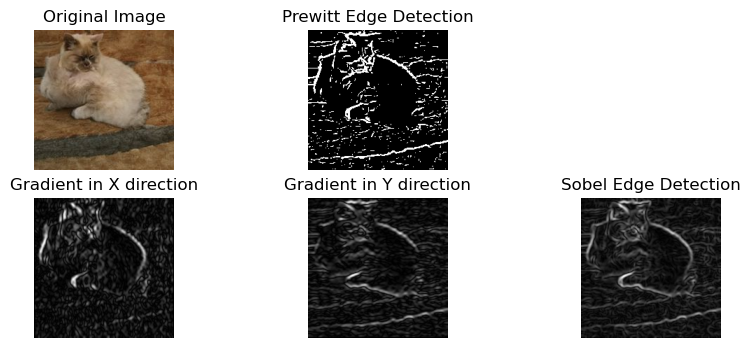

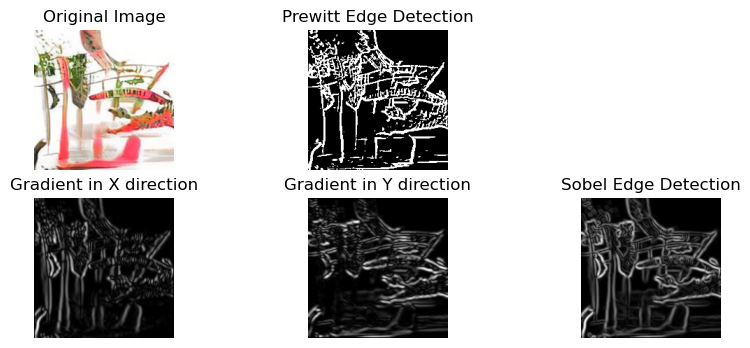

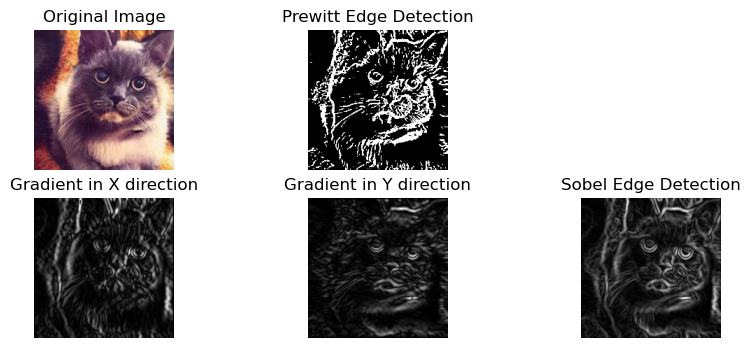

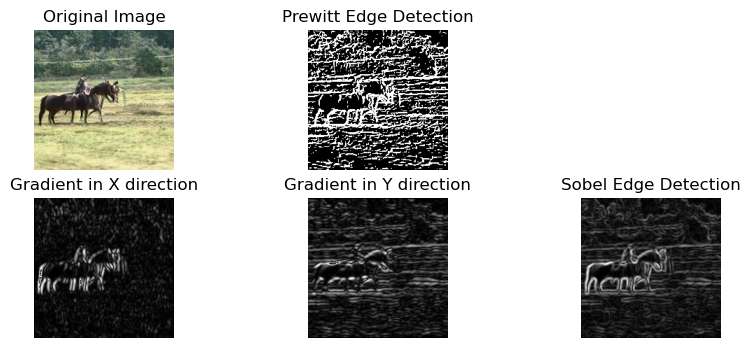

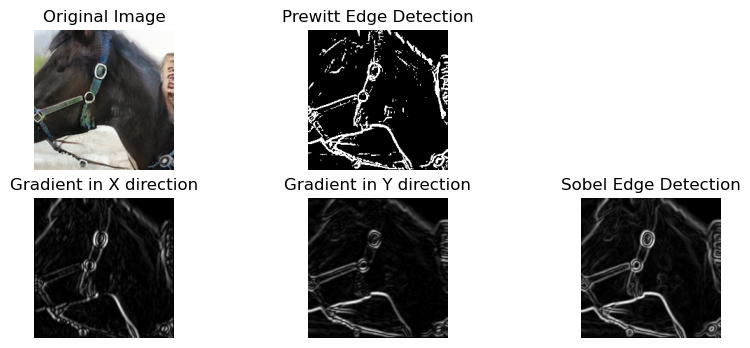

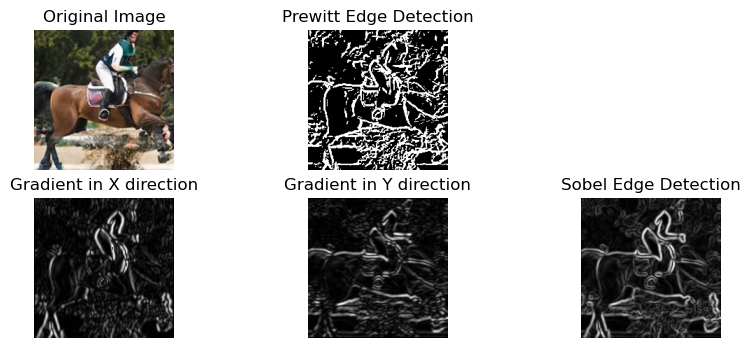

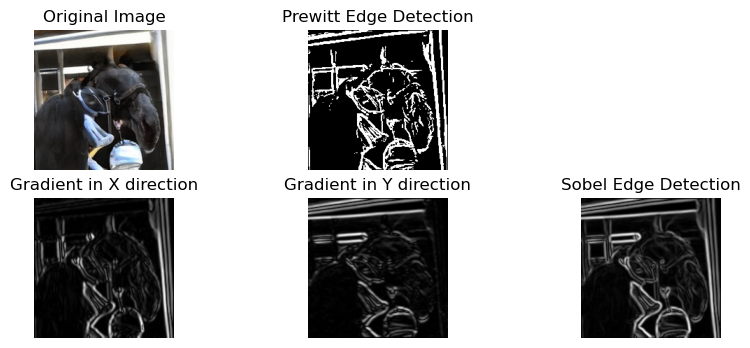

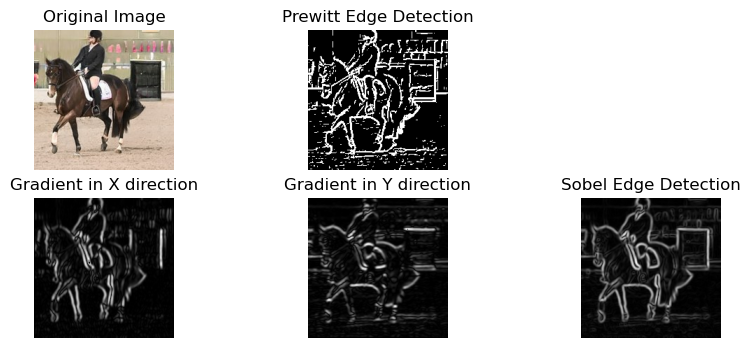

In [70]:
for img, grads in gradient_data[1].items():
    image = cv2.imread(img, cv2.IMREAD_COLOR)
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(prewitt_grads[1][img], cmap='gray')
    plt.title('Prewitt Edge Detection')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(grads[0], cmap='gray')
    plt.title('Gradient in X direction')
    plt.axis('off')
    
    plt.subplot(2, 3, 5)
    plt.imshow(grads[1], cmap='gray')
    plt.title('Gradient in Y direction')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(grads[2], cmap='gray')
    plt.title('Sobel Edge Detection')
    plt.axis('off')

    plt.show()

## Texture Analysis

In [91]:
# helper functions

def compute_glcm(image_path, distances=[5], angles=[0], patch_size=10):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    hei, wid = gray_image.shape
    n_rows, n_cols = hei // patch_size, wid // patch_size

    features = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    feature_maps = {f: np.zeros((n_rows, n_cols)) for f in features}

    for i in range(n_rows):
        for j in range(n_cols):
            patch = gray_image[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            glcm = graycomatrix(patch, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
            for f in features:
                val = graycoprops(glcm, f)[0, 0]
                feature_maps[f][i, j] = val

    return feature_maps

In [92]:
glcm_features = {0: {}, 1: {}}

for class_id in [0, 1]:
    class_path = os.path.join(subset_path, str(class_id))
    
    for file_name in os.listdir(class_path):
         # load image
        image_path = os.path.join(class_path, file_name)
        glcm_features[class_id][image_path] = compute_glcm(image_path)

#### Plot GLCM Features for Real Images

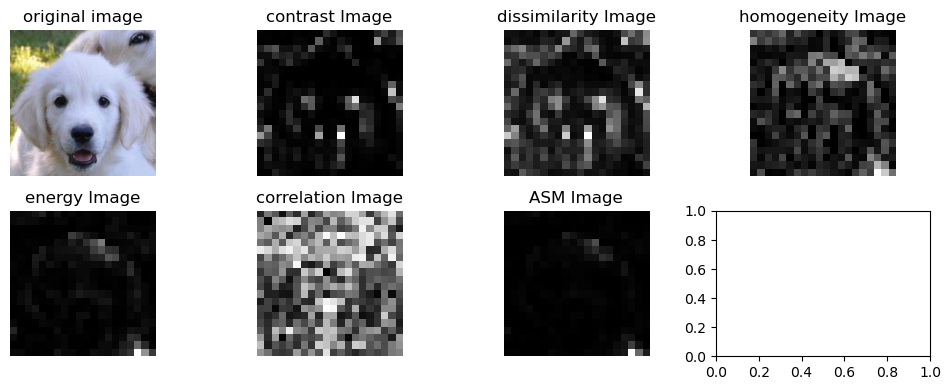

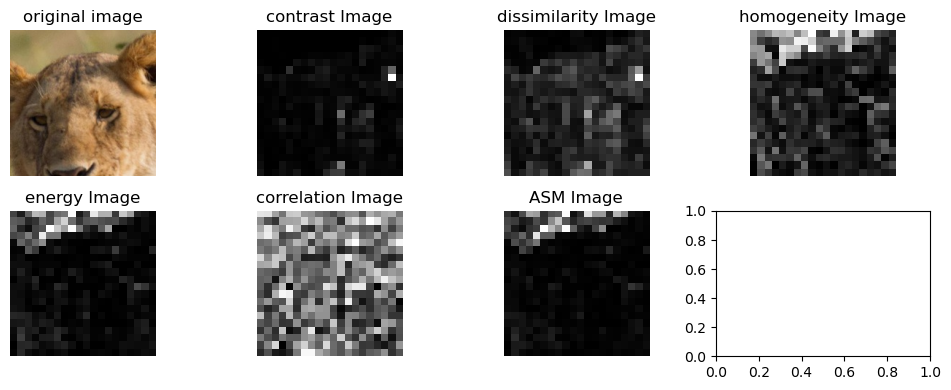

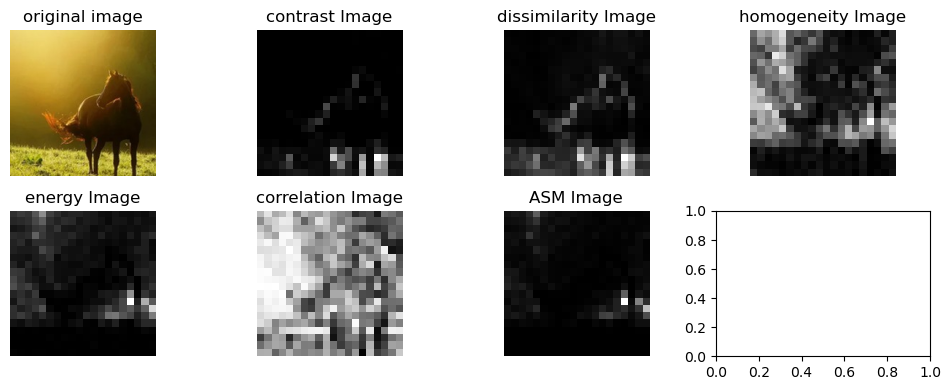

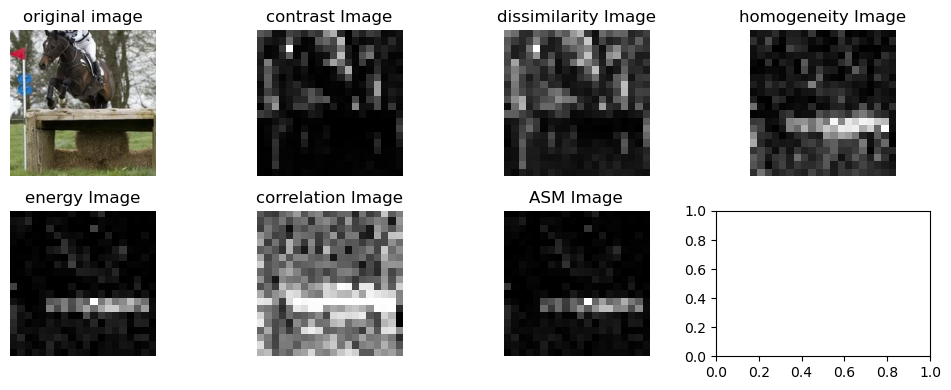

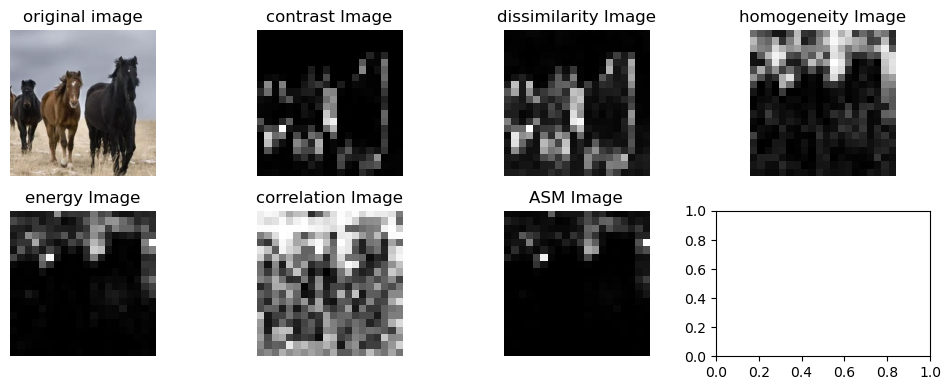

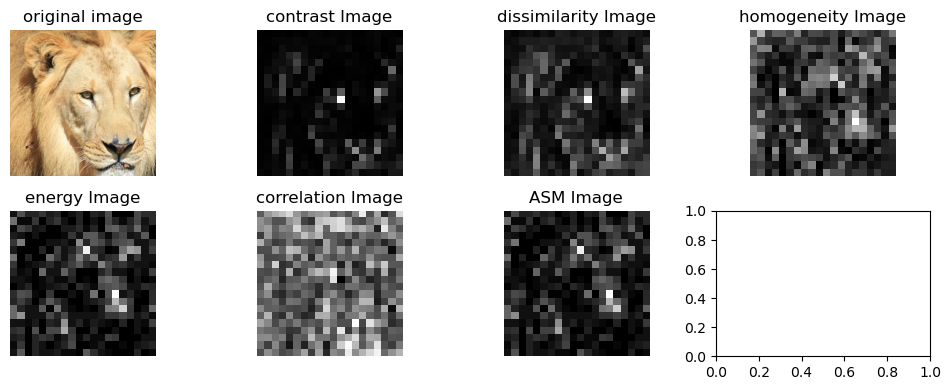

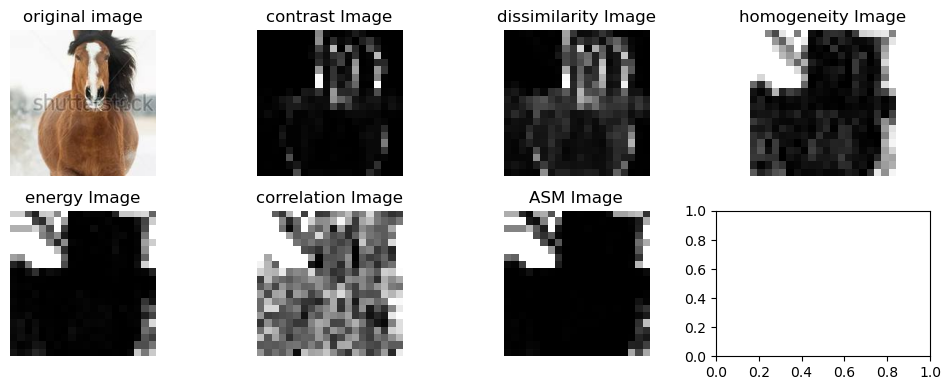

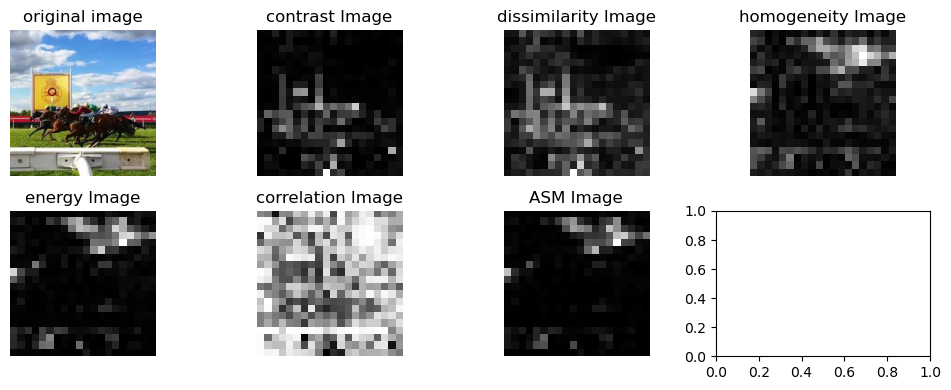

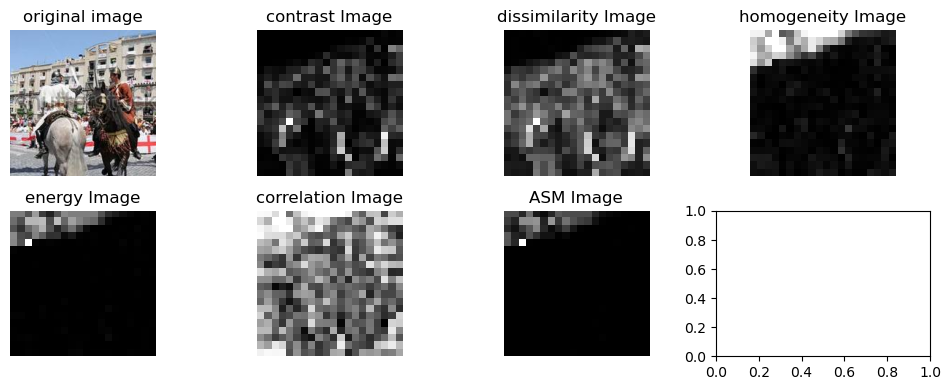

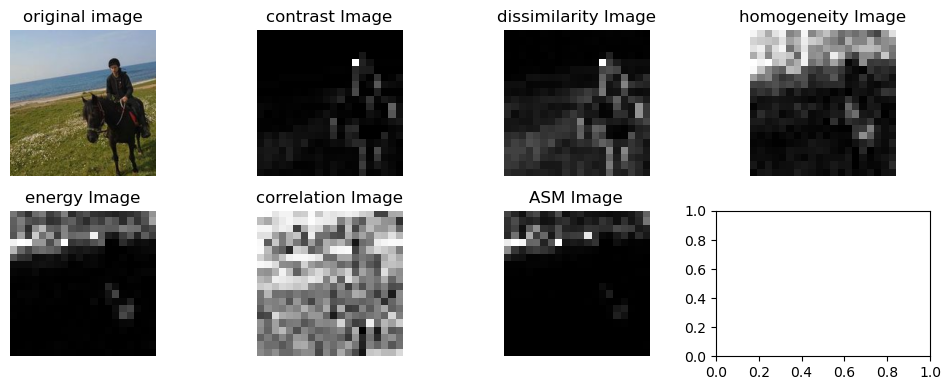

In [93]:
for img, features in glcm_features[0].items():
    features_list = features.keys()
    image = cv2.imread(img, cv2.IMREAD_COLOR)
    fig, axes = plt.subplots(2, 4, figsize=(10, 4))
    axes = axes.ravel()
    
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].axis('off')
    axes[0].set_title('original image')
    
    for ax, feature_name in zip(axes[1:], features_list):
        ax.imshow(features[feature_name], cmap='gray')
        ax.axis('off')
        ax.set_title('{} Image'.format(feature_name))
    
    plt.tight_layout()
    plt.show()

#### Plot GLCM Features for AI-Generated Images

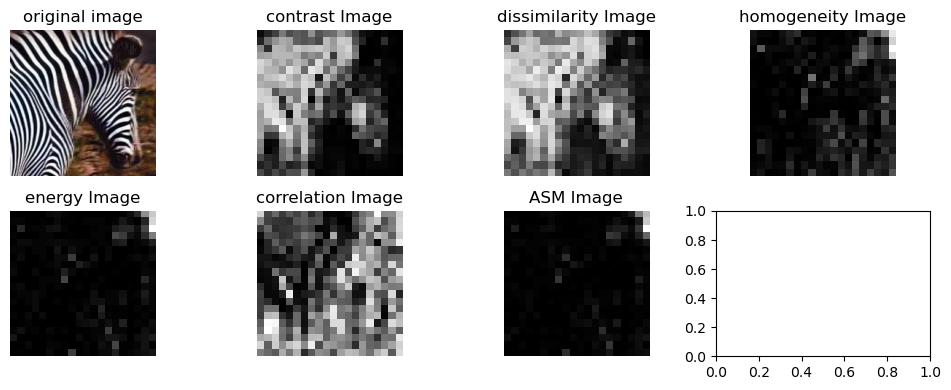

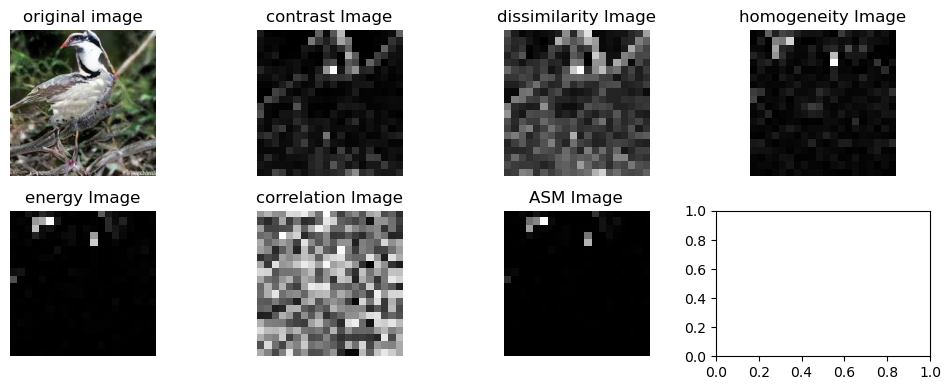

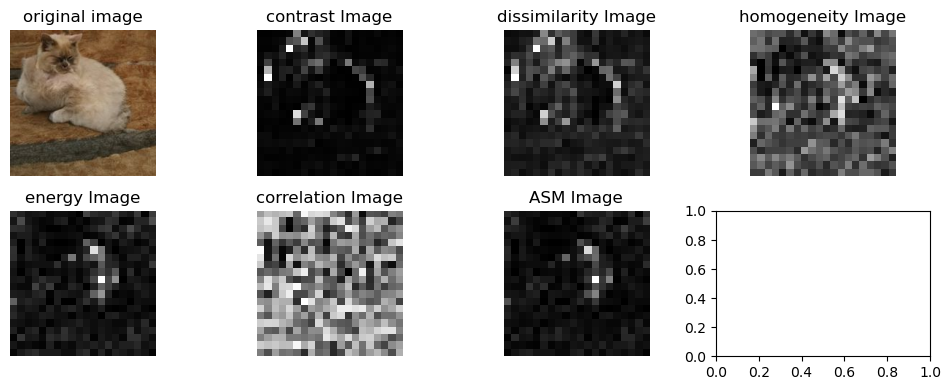

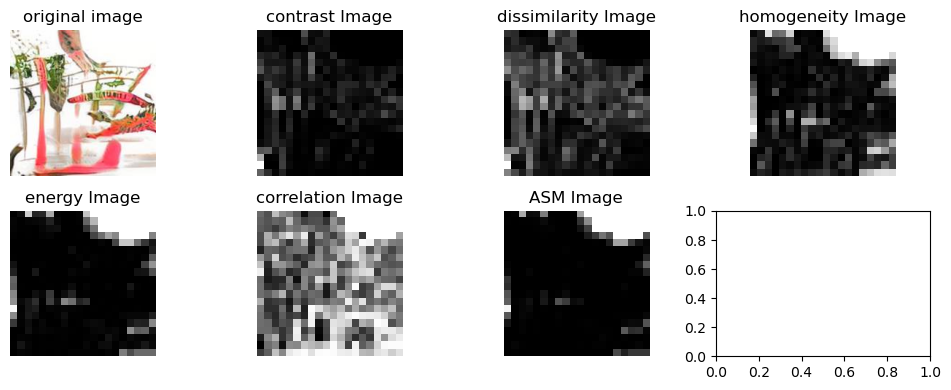

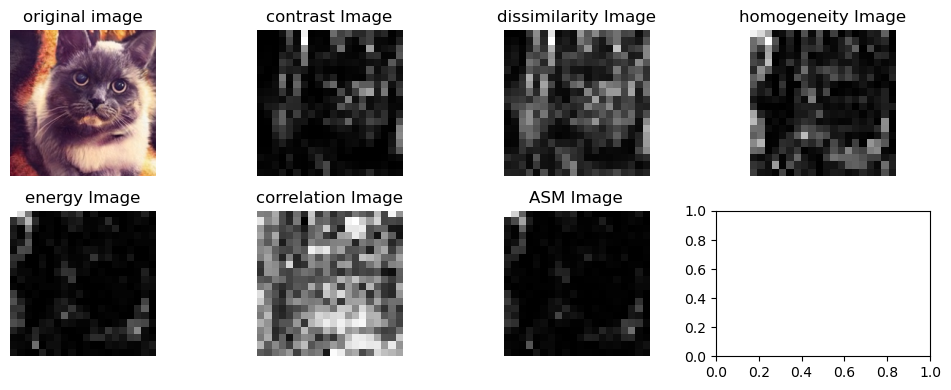

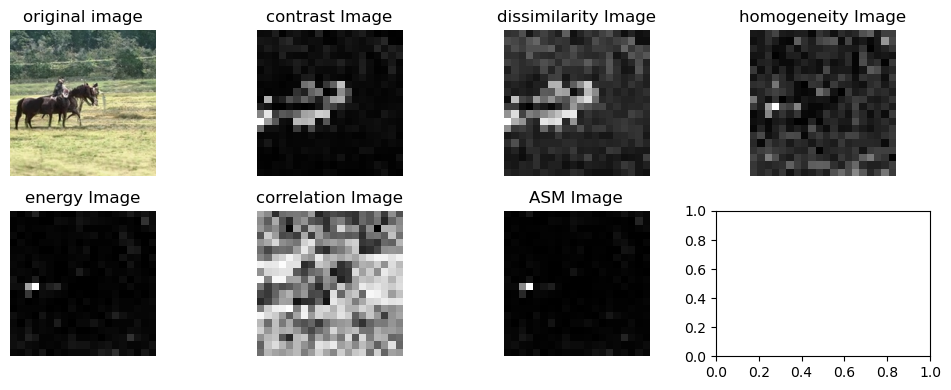

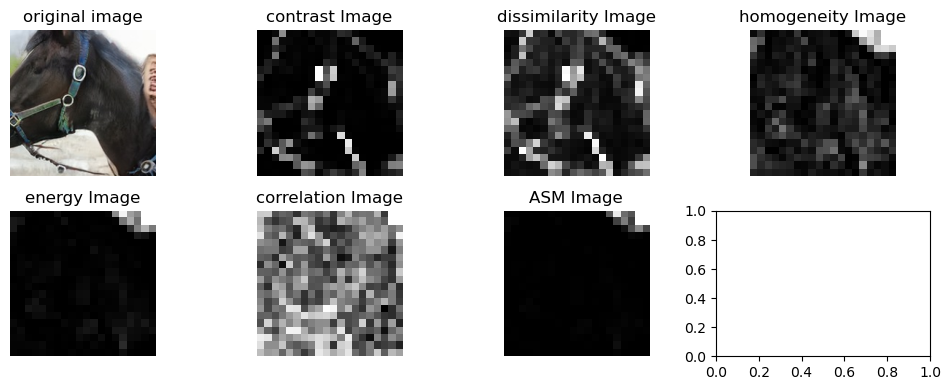

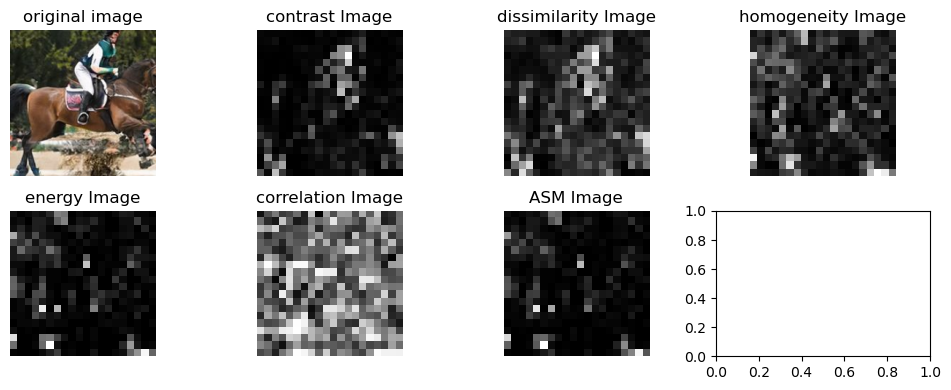

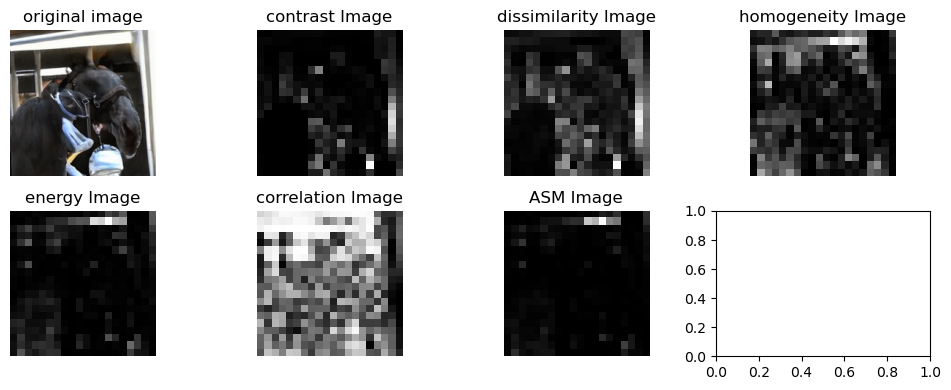

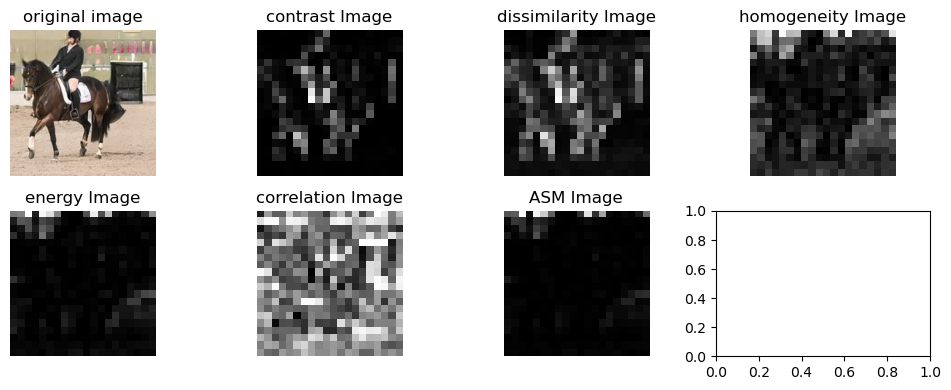

In [94]:
for img, features in glcm_features[1].items():
    features_list = features.keys()
    image = cv2.imread(img, cv2.IMREAD_COLOR)
    fig, axes = plt.subplots(2, 4, figsize=(10, 4))
    axes = axes.ravel()
    
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].axis('off')
    axes[0].set_title('original image')
    
    for ax, feature_name in zip(axes[1:], features_list):
        ax.imshow(features[feature_name], cmap='gray')
        ax.axis('off')
        ax.set_title('{} Image'.format(feature_name))
    
    plt.tight_layout()
    plt.show()